# PRE-PROCESSING

In [2]:
# IMPORT LIBRARY
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub
from google.colab import drive

In [3]:
# DOWNLOAD DATASET
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/DL_Project/seathru_data'
os.makedirs(drive_path, exist_ok=True)
os.environ['KAGGLEHUB_CACHE'] = drive_path
DATA_PATH = kagglehub.dataset_download("colorlabeilat/seathru-dataset")
print("Dataset downloaded in Google Drive at:", DATA_PATH)

Mounted at /content/drive
Using Colab cache for faster access to the 'seathru-dataset' dataset.
Dataset downloaded in Google Drive at: /kaggle/input/seathru-dataset


In [4]:
# CONFIG
SCENES = ["D1", "D2", "D3", "D4", "D5"]

PATCH_SIZE = 256
BATCH_SIZE = 16
SEED = 42

In [5]:
# BUILD IMAGE-DEPTH PAIRS
all_pairs = []

for scene in SCENES:
    base_path = os.path.join(DATA_PATH, scene, scene)

    img_dir = os.path.join(base_path, "linearPNG")

    # D4 special case
    if os.path.exists(os.path.join(base_path, "depth")):
        depth_dir = os.path.join(base_path, "depth")
    elif os.path.exists(os.path.join(base_path, "depth_resized")):
        depth_dir = os.path.join(base_path, "depth_resized")
    else:
        print(f"Skipping {scene}: no depth folder")
        continue

    img_files = sorted(os.listdir(img_dir))
    depth_files = sorted(os.listdir(depth_dir))

    img_dict = {
        os.path.splitext(f)[0]: f
        for f in img_files
    }

    depth_dict = {
        os.path.splitext(f)[0].replace("depth", ""): f
        for f in depth_files
    }

    common_keys = sorted(
        set(img_dict.keys()) & set(depth_dict.keys())
    )

    print(f"{scene}: {len(common_keys)} matched pairs")

    for key in common_keys:
        all_pairs.append(
            (
                os.path.join(img_dir, img_dict[key]),
                os.path.join(depth_dir, depth_dict[key])
            )
        )

print("\nTotal image-depth pairs:", len(all_pairs))

D1: 622 matched pairs
D2: 319 matched pairs
D3: 68 matched pairs
D4: 153 matched pairs
D5: 43 matched pairs

Total image-depth pairs: 1205


In [6]:
# COMPUTE GLOBAL DEPTH MAX
depth_max_values = []

for _, depth_path in all_pairs:
    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth_max_values.append(np.max(depth))

GLOBAL_DEPTH_MAX = np.max(depth_max_values)
print("GLOBAL_DEPTH_MAX:", GLOBAL_DEPTH_MAX)

np.save("global_depth_max.npy", GLOBAL_DEPTH_MAX)

GLOBAL_DEPTH_MAX: 26.075403


In [7]:
# SPLIT BEFORE PATCHING
train_pairs, test_pairs = train_test_split(
    all_pairs,
    test_size=0.15,
    random_state=SEED
)

train_pairs, val_pairs = train_test_split(
    train_pairs,
    test_size=0.15,
    random_state=SEED
)

print(f"Train images: {len(train_pairs)}")
print(f"Val images: {len(val_pairs)}")
print(f"Test images: {len(test_pairs)}")


# save splits
np.save("train_pairs.npy", train_pairs)
np.save("val_pairs.npy", val_pairs)
np.save("test_pairs.npy", test_pairs)

Train images: 870
Val images: 154
Test images: 181


In [8]:
# SAVE CONFIG
config = {
    "PATCH_SIZE": PATCH_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "GLOBAL_DEPTH_MAX": float(GLOBAL_DEPTH_MAX),
    "SEED": SEED
}

np.save("preprocessing_config.npy", config)

In [9]:
# LOADER RGB + DEPTH + MASK
def load_image_depth(img_file, depth_file):
    img = cv2.imread(img_file, cv2.IMREAD_UNCHANGED)

    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

    # auto detect 8-bit or 16-bit
    if img.max() > 255:
        img = img / 65535.0
    else:
        img = img / 255.0

    # normalize RGB to [-1, 1]
    img = img * 2.0 - 1.0

    depth = cv2.imread(depth_file, cv2.IMREAD_UNCHANGED).astype(np.float32)

    # robust valid mask
    valid_mask = np.isfinite(depth).astype(np.float32)
    valid_mask[depth <= 0] = 0

    # hole filling
    hole_mask = (depth <= 0).astype(np.uint8)
    if hole_mask.sum() > 0:
        depth = cv2.inpaint(depth, hole_mask, 3, cv2.INPAINT_NS)

    # normalize depth globally
    depth = depth / GLOBAL_DEPTH_MAX
    depth = np.clip(depth, 0, 1)

    return img, depth, valid_mask

In [10]:
# PATCH GENERATOR
def patch_generator(pairs):
    for img_path, depth_path in pairs:
        result = load_image_depth(img_path, depth_path)

        if result is None:
            continue

        img, depth, mask = result
        h, w = img.shape[:2]

        for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
            for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):

                img_patch = img[
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                depth_patch = depth[
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                mask_patch = mask[
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # skip patches with almost no valid depth
                if np.mean(mask_patch) < 0.05:
                    continue

                yield img_patch, depth_patch, mask_patch

In [11]:
# COUNT PATCHES
train_count = sum(1 for _ in patch_generator(train_pairs))
val_count = sum(1 for _ in patch_generator(val_pairs))
test_count = sum(1 for _ in patch_generator(test_pairs))

print("\nTrain patches:", train_count)
print("Val patches:", val_count)
print("Test patches:", test_count)


Train patches: 44164
Val patches: 7779
Test patches: 9219


In [12]:
# steps per epoch
print("Train steps:", train_count // BATCH_SIZE)
print("Val steps:", val_count // BATCH_SIZE)
print("Test steps:", test_count // BATCH_SIZE)

Train steps: 2760
Val steps: 486
Test steps: 576


In [13]:
# TF.DATA PIPELINE
output_signature = (
    tf.TensorSpec(
        shape=(PATCH_SIZE, PATCH_SIZE, 3),
        dtype=tf.float32
    ),
    tf.TensorSpec(
        shape=(PATCH_SIZE, PATCH_SIZE),
        dtype=tf.float32
    ),
    tf.TensorSpec(
        shape=(PATCH_SIZE, PATCH_SIZE),
        dtype=tf.float32
    ),
)


train_ds = tf.data.Dataset.from_generator(
    lambda: patch_generator(train_pairs),
    output_signature=output_signature
)

val_ds = tf.data.Dataset.from_generator(
    lambda: patch_generator(val_pairs),
    output_signature=output_signature
)

test_ds = tf.data.Dataset.from_generator(
    lambda: patch_generator(test_pairs),
    output_signature=output_signature
)

In [14]:
# AUGMENTATION
@tf.function
def augment(rgb, depth, mask):
    combined = tf.concat(
        [rgb, depth[..., None], mask[..., None]],
        axis=-1
    )

    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_left_right(combined)

    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_up_down(combined)

    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    combined = tf.image.rot90(combined, k)

    rgb = combined[..., :3]
    depth = combined[..., 3]
    mask = combined[..., 4]

    return rgb, depth, mask

In [15]:
# FINAL DATASET PIPELINE
train_ds = (
    train_ds
    .shuffle(200)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

print("\nTF.DATA pipeline ready.")


TF.DATA pipeline ready.


In [16]:
# CHECK SAMPLE BATCH
for rgb, depth, mask in train_ds.take(1):
    print("RGB batch:", rgb.shape)
    print("Depth batch:", depth.shape)
    print("Mask batch:", mask.shape)

RGB batch: (16, 256, 256, 3)
Depth batch: (16, 256, 256)
Mask batch: (16, 256, 256)


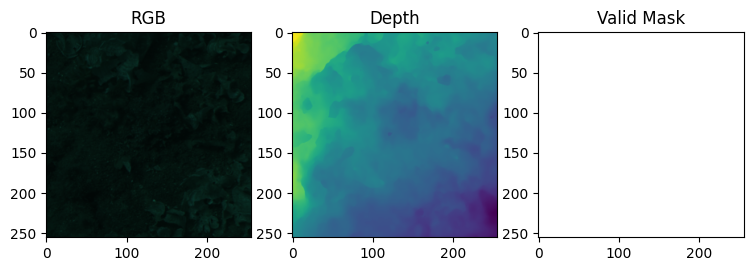

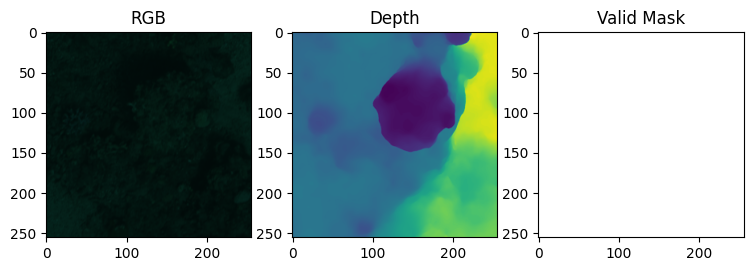

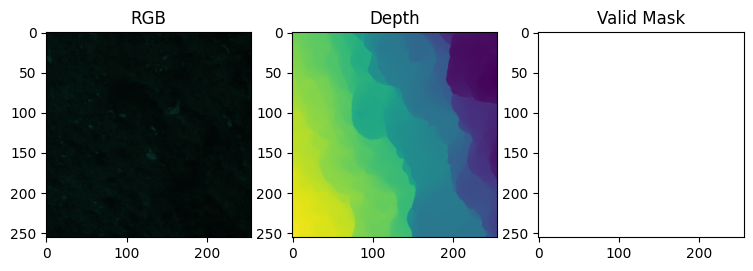

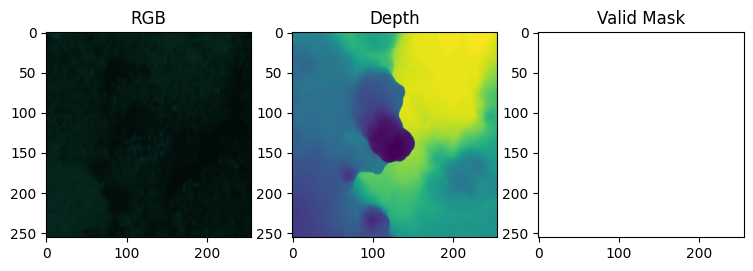

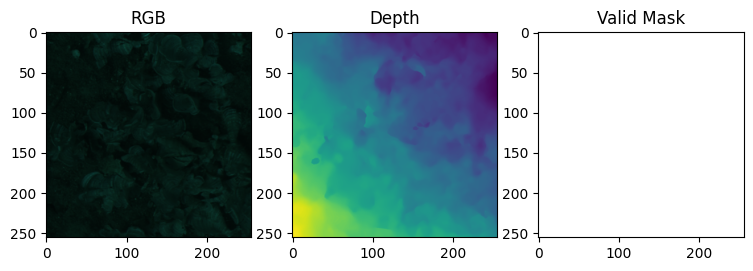

In [17]:
# VISUALIZATION
for rgb_batch, depth_batch, mask_batch in train_ds.take(1):
    for i in range(5):
        plt.figure(figsize=(9, 3))

        plt.subplot(1, 3, 1)
        plt.imshow((rgb_batch[i].numpy() + 1) / 2)
        plt.title("RGB")

        plt.subplot(1, 3, 2)
        plt.imshow(
            depth_batch[i].numpy(),
            cmap="viridis"
        )
        plt.title("Depth")

        plt.subplot(1, 3, 3)
        plt.imshow(
            mask_batch[i].numpy(),
            cmap="gray",
            vmin=0,
            vmax=1
        )
        plt.title("Valid Mask")

        plt.show()

In [18]:
# DEBUG CHECK
# Check valid mask
for i in range(10):
    sample = load_image_depth(
        train_pairs[i][0],
        train_pairs[i][1]
    )

    _, _, mask = sample

    print(
        f"Sample {i}:",
        "unique =", np.unique(mask),
        "mean =", mask.mean()
    )

Sample 0: unique = [1.] mean = 1.0
Sample 1: unique = [0. 1.] mean = 0.8762782
Sample 2: unique = [0. 1.] mean = 0.91807485
Sample 3: unique = [1.] mean = 1.0
Sample 4: unique = [0. 1.] mean = 0.76454335
Sample 5: unique = [0. 1.] mean = 0.99813676
Sample 6: unique = [1.] mean = 1.0
Sample 7: unique = [0. 1.] mean = 0.9992361
Sample 8: unique = [0. 1.] mean = 0.999983
Sample 9: unique = [0. 1.] mean = 0.93871874


In [19]:
# Check RGB bit depth
img = cv2.imread(train_pairs[0][0], cv2.IMREAD_UNCHANGED)
print("dtype:", img.dtype)
print("max:", img.max())
print("min:", img.min())

dtype: uint16
max: 32328
min: 233


In [20]:
# Check normalization ranges
for rgb_batch, depth_batch, mask_batch in train_ds.take(1):
    print("RGB min:", tf.reduce_min(rgb_batch).numpy())
    print("RGB max:", tf.reduce_max(rgb_batch).numpy())

    print("Depth min:", tf.reduce_min(depth_batch).numpy())
    print("Depth max:", tf.reduce_max(depth_batch).numpy())

RGB min: -0.9998169
RGB max: -0.10081637
Depth min: 2.7727196e-09
Depth max: 0.26781043


In [21]:
# Check dataset batches
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: -1
Val batches: -2
Test batches: -2


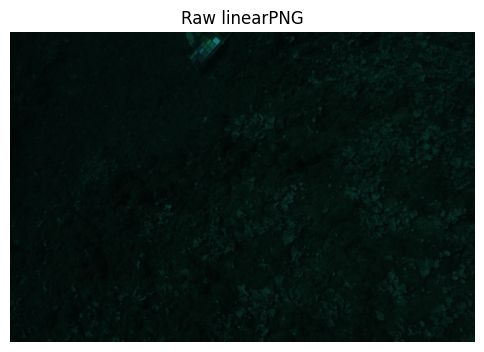

In [22]:
img = cv2.imread(train_pairs[0][0], cv2.IMREAD_UNCHANGED)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img / 65535.0)
plt.title("Raw linearPNG")
plt.axis("off")
plt.show()

# MODELING

## Libraries

In [23]:
from tensorflow.keras import layers, Model
import cv2

## Load Preprocessing Outputs

In [24]:
train_pairs      = np.load("train_pairs.npy",          allow_pickle=True)
val_pairs        = np.load("val_pairs.npy",             allow_pickle=True)
test_pairs       = np.load("test_pairs.npy",            allow_pickle=True)
config           = np.load("preprocessing_config.npy",  allow_pickle=True).item()
GLOBAL_DEPTH_MAX = np.load("global_depth_max.npy")

In [25]:
PATCH_SIZE = config["PATCH_SIZE"]   # 256
BATCH_SIZE = config["BATCH_SIZE"]   # 16
SEED       = config["SEED"]         # 42

In [26]:
train_count = 44164
val_count   = 7779
test_count  = 9219
train_steps = train_count // BATCH_SIZE
val_steps   = val_count   // BATCH_SIZE
test_steps  = test_count  // BATCH_SIZE

## Physics-Based Target Generator

In [27]:
def grey_world_wb(img_01):
    """img_01: H x W x 3, float32 in [0,1]. Returns [0,1]."""
    mean = img_01.mean(axis=(0, 1), keepdims=True)          # (1,1,3)
    gray = mean.mean(axis=-1, keepdims=True)                 # (1,1,1)
    scale = np.where(mean > 1e-6, gray / mean, 1.0)
    return np.clip(img_01 * scale, 0, 1)

In [28]:
def hist_eq_rgb(img_01):
    """Per-channel CLAHE-style equalization."""
    img_u8 = (img_01 * 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    out    = np.stack([clahe.apply(img_u8[..., c]) for c in range(3)], axis=-1)
    return out.astype(np.float32) / 255.0

In [29]:
def gamma_correct_np(img_01, gamma=2.2):
    return np.clip(img_01, 1e-7, 1.0) ** (1.0 / gamma)

In [30]:
def build_target(img_01):
    """
    Fuse WB + HistEq + Gamma into one enhanced target image.
    Simple equal-weight average — good enough for supervision.
    """
    wb   = grey_world_wb(img_01)
    hist = hist_eq_rgb(img_01)
    gam  = gamma_correct_np(img_01)
    fused = (wb + hist + gam) / 3.0
    return np.clip(fused, 0, 1)

## Patch Generator -> yields (raw_patch, target_patch)

In [31]:
def load_image(img_file):
    img = cv2.imread(img_file, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    img = img / 65535.0 if img.max() > 255 else img / 255.0
    return img   # [0,1]

In [32]:
def patch_generator(pairs):
    for img_path, _ in pairs:                 # depth not needed for labels
        img_01 = load_image(img_path)
        if img_01 is None:
            continue
        target_01 = build_target(img_01)

        # normalise to [-1, 1] for the network
        raw    = img_01    * 2.0 - 1.0
        target = target_01 * 2.0 - 1.0

        h, w = raw.shape[:2]
        for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
            for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
                raw_p    = raw   [y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                target_p = target[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                yield raw_p.astype(np.float32), target_p.astype(np.float32)

In [33]:
output_sig = (
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),  # input
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),  # target
)

## Augmentation

In [34]:
@tf.function
def augment(raw, target):
    combined = tf.concat([raw, target], axis=-1)   # (H,W,6)
    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_left_right(combined)
    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_up_down(combined)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    combined = tf.image.rot90(combined, k)
    return combined[..., :3], combined[..., 3:]

## tf.Data Pipeline

In [35]:
train_ds = (
    tf.data.Dataset.from_generator(lambda: patch_generator(train_pairs), output_signature=output_sig)
    .shuffle(500)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)

In [36]:
val_ds = (
    tf.data.Dataset.from_generator(lambda: patch_generator(val_pairs), output_signature=output_sig)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

In [37]:
test_ds = (
    tf.data.Dataset.from_generator(lambda: patch_generator(test_pairs), output_signature=output_sig)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

In [38]:
# sanity check
for raw_b, tgt_b in train_ds.take(1):
    print("Input  shape:", raw_b.shape, " range:", raw_b.numpy().min(), raw_b.numpy().max())
    print("Target shape:", tgt_b.shape, " range:", tgt_b.numpy().min(), tgt_b.numpy().max())

Input  shape: (16, 256, 256, 3)  range: -0.9994812 -0.086900115
Target shape: (16, 256, 256, 3)  range: -0.97590494 0.15298831


## Building Blocks

In [39]:
def conv_bn_relu(x, filters, kernel=3):
    x = layers.Conv2D(filters, kernel, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.ReLU()(x)

In [40]:
def encoder_block(x, filters):
    x    = conv_bn_relu(x, filters)
    x    = conv_bn_relu(x, filters)
    skip = x
    return layers.MaxPooling2D(2)(x), skip

In [41]:
def decoder_block(x, skip, filters):
    x = layers.UpSampling2D(2)(x)
    x = layers.Concatenate()([x, skip])
    x = conv_bn_relu(x, filters)
    return conv_bn_relu(x, filters)

## Teacher: WaterNet  
Three branches (WB / Hist / Gamma inputs) + fusion head

In [42]:
def tf_wb(x):
    """TF version of grey-world WB. x in [-1,1]."""
    x01   = (x + 1.0) / 2.0
    mean  = tf.reduce_mean(x01, axis=[1, 2], keepdims=True)
    gray  = tf.reduce_mean(mean, axis=-1, keepdims=True)
    scale = tf.math.divide_no_nan(gray, mean)
    return tf.clip_by_value(x01 * scale, 0, 1) * 2.0 - 1.0

In [43]:
def tf_hist(x):
    x01 = (x + 1.0) / 2.0
    return tf.math.pow(x01, 0.5) * 2.0 - 1.0    # approx histogram stretch

In [44]:
def tf_gamma(x, g=2.2):
    x01 = tf.clip_by_value((x + 1.0) / 2.0, 1e-7, 1.0)
    return tf.math.pow(x01, 1.0 / g) * 2.0 - 1.0

In [45]:
def build_branch(name, filters=32):
    inp = layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 3))
    x   = conv_bn_relu(inp, filters)
    x   = conv_bn_relu(x,   filters)
    x   = conv_bn_relu(x,   filters * 2)
    x   = conv_bn_relu(x,   filters * 2)
    out = conv_bn_relu(x,   filters)
    return Model(inp, out, name=name)

In [46]:
def build_waternet():
    raw_in = layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 3), name="raw_in")

    wb_feat   = build_branch("wb_branch")  (layers.Lambda(tf_wb)  (raw_in))
    hist_feat = build_branch("hist_branch")(layers.Lambda(tf_hist) (raw_in))
    gam_feat  = build_branch("gam_branch") (layers.Lambda(tf_gamma)(raw_in))

    fused = layers.Concatenate()([wb_feat, hist_feat, gam_feat, raw_in])
    x     = conv_bn_relu(fused, 64)
    x     = conv_bn_relu(x,     32)
    out   = layers.Conv2D(3, 3, padding="same", activation="tanh", name="teacher_out")(x)
    return Model(raw_in, out, name="WaterNet_Teacher")

In [47]:
teacher = build_waternet()
teacher.summary()

Model: "WaterNet_Teacher"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_in (InputLayer) │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256, 256,  │          0 │ raw_in[0][0]      │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 256, 256,  │          0 │ raw_in[0][0]      │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 256, 256,  │          0 │ raw_in[0][0]      │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wb_branch           │ (None, 256, 256,  │     84,704 │ lambda[0][0]      │
│ (Functional)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hist_branch         │ (None, 256, 256,  │     84,704 │ lambda_1[0][0]    │
│ (Functional)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gam_branch          │ (None, 256, 256,  │     84,704 │ lambda_2[0][0]    │
│ (Functional)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ wb_branch[0][0],  │
│ (Concatenate)       │ 99)               │            │ hist_branch[0][0… │
│                     │                   │            │ gam_branch[0][0], │
│                     │                   │            │ raw_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 256, 256,  │     57,024 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │     18,432 │ re_lu_15[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ teacher_out         │ (None, 256, 256,  │        867 │ re_lu_16[0][0]    │
│ (Conv2D)            │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 330,819 (1.26 MB)

 Trainable params: 329,283 (1.26 MB)

 Non-trainable params: 1,536 (6.00 KB)

## Student: Shallow U-Net  (3 levels)

In [48]:
def build_student_unet():
    inp        = layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 3))
    x, s1      = encoder_block(inp, 32)
    x, s2      = encoder_block(x,   64)
    x, s3      = encoder_block(x,   128)
    x          = conv_bn_relu(conv_bn_relu(x, 256), 256)
    x          = decoder_block(x, s3, 128)
    x          = decoder_block(x, s2,  64)
    x          = decoder_block(x, s1,  32)
    out        = layers.Conv2D(3, 1, padding="same", activation="tanh")(x)
    return Model(inp, out, name="Student_ShallowUNet")

In [49]:
student = build_student_unet()
student.summary()

Model: "Student_ShallowUNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 256, 256,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 256, 256,  │      9,216 │ re_lu_17[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_18[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │     36,864 │ re_lu_19[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_20[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_21[0][0] 

 Total params: 1,951,171 (7.44 MB)

 Trainable params: 1,948,355 (7.43 MB)

 Non-trainable params: 2,816 (11.00 KB)

## Baseline: UGAN

In [50]:
def build_ugan_generator():
    inp   = layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 3))
    x, s1 = encoder_block(inp, 32)
    x, s2 = encoder_block(x,   64)
    x, s3 = encoder_block(x,   128)
    x     = conv_bn_relu(conv_bn_relu(x, 256), 256)
    x     = decoder_block(x, s3, 128)
    x     = decoder_block(x, s2,  64)
    x     = decoder_block(x, s1,  32)
    out   = layers.Conv2D(3, 1, padding="same", activation="tanh")(x)
    return Model(inp, out, name="UGAN_Generator")

In [51]:
def build_ugan_discriminator():
    inp = layers.Input(shape=(PATCH_SIZE, PATCH_SIZE, 3))
    x   = layers.LeakyReLU(0.2)(layers.Conv2D(32,  4, strides=2, padding="same")(inp))
    x   = layers.LeakyReLU(0.2)(layers.BatchNormalization()(layers.Conv2D(64,  4, strides=2, padding="same")(x)))
    x   = layers.LeakyReLU(0.2)(layers.BatchNormalization()(layers.Conv2D(128, 4, strides=2, padding="same")(x)))
    out = layers.Conv2D(1, 4, strides=1, padding="same")(x)
    return Model(inp, out, name="UGAN_Discriminator")

In [52]:
ugan_gen  = build_ugan_generator()
ugan_disc = build_ugan_discriminator()

## Loss & Optimizers

In [53]:
mae_loss = tf.keras.losses.MeanAbsoluteError()
bce_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [54]:
def pixel_loss(y_true, y_pred):
    return mae_loss(y_true, y_pred)

In [55]:
def multiscale_loss(y_true, y_pred):
    loss = mae_loss(y_true, y_pred)
    t2   = tf.nn.avg_pool2d(y_true, 2, 2, "VALID")
    p2   = tf.nn.avg_pool2d(y_pred, 2, 2, "VALID")
    loss += mae_loss(t2, p2) * 0.5
    t4   = tf.nn.avg_pool2d(t2, 2, 2, "VALID")
    p4   = tf.nn.avg_pool2d(p2, 2, 2, "VALID")
    loss += mae_loss(t4, p4) * 0.25
    return loss

In [56]:
LAMBDA_PIXEL = 100.0
LAMBDA_KD    = 5.0

In [57]:
teacher_opt  = tf.keras.optimizers.Adam(1e-4)
student_opt  = tf.keras.optimizers.Adam(1e-4)
ugan_gen_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
ugan_dis_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

## TRAIN STEPS

In [58]:
@tf.function
def train_teacher_step(raw, target):
    with tf.GradientTape() as tape:
        pred = teacher(raw, training=True)
        loss = multiscale_loss(target, pred)
    grads = tape.gradient(loss, teacher.trainable_variables)
    teacher_opt.apply_gradients(zip(grads, teacher.trainable_variables))
    return loss

In [59]:
@tf.function
def train_student_step(raw, target):
    teacher_pred = teacher(raw, training=False)
    with tf.GradientTape() as tape:
        student_pred = student(raw, training=True)
        task_loss = multiscale_loss(target, student_pred)
        kd_loss   = mae_loss(teacher_pred, student_pred) * LAMBDA_KD
        loss      = task_loss + kd_loss
    grads = tape.gradient(loss, student.trainable_variables)
    student_opt.apply_gradients(zip(grads, student.trainable_variables))
    return loss, task_loss, kd_loss

In [60]:
@tf.function
def train_ugan_step(raw, target):
    with tf.GradientTape() as disc_tape:
        fake   = ugan_gen(raw, training=False)
        d_real = ugan_disc(target, training=True)
        d_fake = ugan_disc(fake,   training=True)
        d_loss = (bce_loss(tf.ones_like(d_real),  d_real) +
                  bce_loss(tf.zeros_like(d_fake), d_fake))
    disc_grads = disc_tape.gradient(d_loss, ugan_disc.trainable_variables)
    ugan_dis_opt.apply_gradients(zip(disc_grads, ugan_disc.trainable_variables))

    with tf.GradientTape() as gen_tape:
        fake   = ugan_gen(raw, training=True)
        d_fake = ugan_disc(fake, training=False)
        g_adv  = bce_loss(tf.ones_like(d_fake), d_fake)
        g_pix  = mae_loss(target, fake) * LAMBDA_PIXEL
        g_loss = g_adv + g_pix
    gen_grads = gen_tape.gradient(g_loss, ugan_gen.trainable_variables)
    ugan_gen_opt.apply_gradients(zip(gen_grads, ugan_gen.trainable_variables))
    return g_loss, d_loss

## Metrics

In [61]:
def compute_psnr_ssim(model, dataset, steps):
    psnr_vals, ssim_vals = [], []
    for step, (raw, target) in enumerate(dataset):
        if step >= steps:
            break
        pred    = model(raw, training=False)
        p01     = tf.clip_by_value((pred   + 1) / 2, 0, 1)
        t01     = tf.clip_by_value((target + 1) / 2, 0, 1)
        psnr_vals.append(tf.reduce_mean(tf.image.psnr(t01, p01, 1.0)).numpy())
        ssim_vals.append(tf.reduce_mean(tf.image.ssim(t01, p01, 1.0)).numpy())
    return float(np.mean(psnr_vals)), float(np.mean(ssim_vals))

# TRAINING

In [73]:
EPOCHS_TEACHER = 30
EPOCHS_STUDENT = 30
EPOCHS_UGAN    = 10

In [63]:
history = {
    "teacher_train": [], "teacher_val": [],
    "student_train": [], "student_val": [],
    "ugan_gen": [],      "ugan_disc":   [],
}

## Phase 1: Train Teacher

In [64]:
"""
print("\n" + "="*50)
print("PHASE 1: Training Teacher (WaterNet)")
print("="*50)

for epoch in range(EPOCHS_TEACHER):
    t_losses = []
    for step, (raw, target) in enumerate(train_ds):
        if step >= train_steps:
            break
        loss = train_teacher_step(raw, target)
        t_losses.append(loss.numpy())
        if step % 500 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS_TEACHER} | Step {step}/{train_steps} | Loss: {loss:.4f}")

    v_losses = []
    for step, (raw, target) in enumerate(val_ds):
        if step >= val_steps:
            break
        pred = teacher(raw, training=False)
        v_losses.append(multiscale_loss(target, pred).numpy())

    tl = np.mean(t_losses); vl = np.mean(v_losses)
    history["teacher_train"].append(tl)
    history["teacher_val"].append(vl)
    print(f"Epoch {epoch+1}/{EPOCHS_TEACHER} | Train: {tl:.4f} | Val: {vl:.4f}")

teacher.save("teacher_waternet.keras")
print("Teacher saved.")
"""

'\nprint("\n" + "="*50)\nprint("PHASE 1: Training Teacher (WaterNet)")\nprint("="*50)\n\nfor epoch in range(EPOCHS_TEACHER):\n    t_losses = []\n    for step, (raw, target) in enumerate(train_ds):\n        if step >= train_steps:\n            break\n        loss = train_teacher_step(raw, target)\n        t_losses.append(loss.numpy())\n        if step % 500 == 0:\n            print(f"  Epoch {epoch+1}/{EPOCHS_TEACHER} | Step {step}/{train_steps} | Loss: {loss:.4f}")\n\n    v_losses = []\n    for step, (raw, target) in enumerate(val_ds):\n        if step >= val_steps:\n            break\n        pred = teacher(raw, training=False)\n        v_losses.append(multiscale_loss(target, pred).numpy())\n\n    tl = np.mean(t_losses); vl = np.mean(v_losses)\n    history["teacher_train"].append(tl)\n    history["teacher_val"].append(vl)\n    print(f"Epoch {epoch+1}/{EPOCHS_TEACHER} | Train: {tl:.4f} | Val: {vl:.4f}")\n\nteacher.save("teacher_waternet.keras")\nprint("Teacher saved.")\n'

In [65]:
#!ls -lh /content/*.keras

ls: cannot access '/content/*.keras': No such file or directory


In [70]:
print("Loading pre-trained Teacher (WaterNet)...")

teacher = tf.keras.models.load_model(
    "/content/drive/MyDrive/DL_Project/teacher_waternet.keras",
    custom_objects={
        'tf_wb': tf_wb,
        'tf_hist': tf_hist,
        'tf_gamma': tf_gamma
    },
    compile=False
)

print("Teacher loaded successfully. Ready for Phase 2.")

Loading pre-trained Teacher (WaterNet)...
Teacher loaded successfully. Ready for Phase 2.


## Phase 2: Train Student

In [71]:
# Define the permanent Drive path
STUDENT_SAVE_PATH = "/content/drive/MyDrive/DL_Project/student_checkpoint.keras"

In [72]:
print("\n" + "="*50)
print("PHASE 2: Training Student (Shallow U-Net + KD)")
print("="*50)

# Resume Check
if os.path.exists(STUDENT_SAVE_PATH):
    print("Found existing Student checkpoint. Resuming training...")
    student = tf.keras.models.load_model(STUDENT_SAVE_PATH)
else:
    print("No checkpoint found. Starting Student from scratch...")

# Training Loop
for epoch in range(EPOCHS_STUDENT):
    t_losses = []
    for step, (raw, target) in enumerate(train_ds):
        if step >= train_steps:
            break
        loss, task_l, kd_l = train_student_step(raw, target)
        t_losses.append(loss.numpy())
        if step % 500 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS_STUDENT} | Step {step}/{train_steps} | Loss: {loss:.4f} (task: {task_l:.4f} | kd: {kd_l:.4f})")

    v_losses = []
    for step, (raw, target) in enumerate(val_ds):
        if step >= val_steps:
            break
        pred = student(raw, training=False)
        v_losses.append(multiscale_loss(target, pred).numpy())

    tl = np.mean(t_losses)
    vl = np.mean(v_losses)
    history["student_train"].append(tl)
    history["student_val"].append(vl)
    print(f"Epoch {epoch+1}/{EPOCHS_STUDENT} | Train: {tl:.4f} | Val: {vl:.4f}")

    # Epoch Checkpoint: Save immediately to Drive after every single epoch
    student.save(STUDENT_SAVE_PATH)
    print(f"[*] Checkpoint secured to Drive for Epoch {epoch+1}.")

print("Student training complete.")


PHASE 2: Training Student (Shallow U-Net + KD)
No checkpoint found. Starting Student from scratch...
  Epoch 1/30 | Step 0/2760 | Loss: 5.2071 (task: 1.3426 | kd: 3.8645)
  Epoch 1/30 | Step 500/2760 | Loss: 0.2769 (task: 0.0720 | kd: 0.2049)
  Epoch 1/30 | Step 1000/2760 | Loss: 0.1427 (task: 0.0386 | kd: 0.1041)
  Epoch 1/30 | Step 1500/2760 | Loss: 0.1866 (task: 0.0434 | kd: 0.1432)
  Epoch 1/30 | Step 2000/2760 | Loss: 0.2067 (task: 0.0504 | kd: 0.1562)
  Epoch 1/30 | Step 2500/2760 | Loss: 0.1506 (task: 0.0444 | kd: 0.1062)
Epoch 1/30 | Train: 0.3101 | Val: 0.0467
[*] Checkpoint secured to Drive for Epoch 1.
  Epoch 2/30 | Step 0/2760 | Loss: 0.2003 (task: 0.0473 | kd: 0.1530)
  Epoch 2/30 | Step 500/2760 | Loss: 0.1257 (task: 0.0352 | kd: 0.0904)
  Epoch 2/30 | Step 1000/2760 | Loss: 0.1593 (task: 0.0370 | kd: 0.1224)
  Epoch 2/30 | Step 1500/2760 | Loss: 0.1300 (task: 0.0329 | kd: 0.0971)
  Epoch 2/30 | Step 2000/2760 | Loss: 0.0774 (task: 0.0216 | kd: 0.0558)
  Epoch 2/30 | St

KeyboardInterrupt: 

## Phase 3: Train UGAN Baseline

In [74]:
# Define permanent Drive paths for BOTH models
GEN_SAVE_PATH = "/content/drive/MyDrive/DL_Project/ugan_gen_checkpoint.keras"
DISC_SAVE_PATH = "/content/drive/MyDrive/DL_Project/ugan_disc_checkpoint.keras"

In [75]:
print("\n" + "="*50)
print("PHASE 3: Training UGAN Baseline")
print("="*50)

# Resume Check (Requires both models to maintain adversarial balance)
if os.path.exists(GEN_SAVE_PATH) and os.path.exists(DISC_SAVE_PATH):
    print("Found existing UGAN checkpoints. Resuming training...")
    ugan_gen = tf.keras.models.load_model(GEN_SAVE_PATH)
    ugan_disc = tf.keras.models.load_model(DISC_SAVE_PATH)
else:
    print("No complete checkpoints found. Starting UGAN from scratch...")

# Training Loop
for epoch in range(EPOCHS_UGAN):
    g_losses, d_losses = [], []

    for step, (raw, target) in enumerate(train_ds):
        if step >= train_steps:
            break
        g_loss, d_loss = train_ugan_step(raw, target)
        g_losses.append(g_loss.numpy())
        d_losses.append(d_loss.numpy())

        if step % 500 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS_UGAN} | Step {step}/{train_steps} | G: {g_loss:.4f} | D: {d_loss:.4f}")

    history["ugan_gen"].append(np.mean(g_losses))
    history["ugan_disc"].append(np.mean(d_losses))
    print(f"Epoch {epoch+1}/{EPOCHS_UGAN} | Gen: {np.mean(g_losses):.4f} | Disc: {np.mean(d_losses):.4f}")

    # Epoch Checkpoint: Save BOTH models to Drive immediately
    ugan_gen.save(GEN_SAVE_PATH)
    ugan_disc.save(DISC_SAVE_PATH)
    print(f"[*] Both Generator and Discriminator checkpoints secured to Drive for Epoch {epoch+1}.")

print("UGAN training complete.")


PHASE 3: Training UGAN Baseline
No complete checkpoints found. Starting UGAN from scratch...
  Epoch 1/10 | Step 0/2760 | G: 81.6447 | D: 1.5751
  Epoch 1/10 | Step 500/2760 | G: 4.2070 | D: 0.0134
  Epoch 1/10 | Step 1000/2760 | G: 4.8008 | D: 0.1747
  Epoch 1/10 | Step 1500/2760 | G: 6.2515 | D: 0.0299
  Epoch 1/10 | Step 2000/2760 | G: 4.0868 | D: 0.0691
  Epoch 1/10 | Step 2500/2760 | G: 4.7330 | D: 0.0076
Epoch 1/10 | Gen: 6.1051 | Disc: 0.1515
[*] Both Generator and Discriminator checkpoints secured to Drive for Epoch 1.
  Epoch 2/10 | Step 0/2760 | G: 4.5042 | D: 0.0102
  Epoch 2/10 | Step 500/2760 | G: 3.5793 | D: 0.0050
  Epoch 2/10 | Step 1000/2760 | G: 3.6179 | D: 0.0017
  Epoch 2/10 | Step 1500/2760 | G: 5.0039 | D: 0.0026
  Epoch 2/10 | Step 2000/2760 | G: 7.0965 | D: 0.0051
  Epoch 2/10 | Step 2500/2760 | G: 5.4450 | D: 0.0184
Epoch 2/10 | Gen: 4.9647 | Disc: 0.0383
[*] Both Generator and Discriminator checkpoints secured to Drive for Epoch 2.
  Epoch 3/10 | Step 0/2760 

# EVALUATION

In [88]:
DRIVE_PATH = "/content/drive/MyDrive/DL_Project/"

# The custom operations required ONLY by the Teacher (WaterNet)
waternet_objects = {
    'tf_wb': tf_wb,
    'tf_hist': tf_hist,
    'tf_gamma': tf_gamma
}

print("Loading models...")

# Teacher requires the custom objects injection
teacher  = tf.keras.models.load_model(
    DRIVE_PATH + "teacher_waternet.keras",
    custom_objects=waternet_objects,
    compile=False
)
print("Teacher loaded.")

# Student and UGAN are standard architectures, they load normally
student  = tf.keras.models.load_model(DRIVE_PATH + "student_checkpoint.keras", compile=False)
print("Student loaded.")

ugan_gen = tf.keras.models.load_model(DRIVE_PATH + "ugan_gen_checkpoint.keras", compile=False)
print("UGAN Generator loaded.")

ugan_disc = tf.keras.models.load_model(DRIVE_PATH + "ugan_disc_checkpoint.keras", compile=False)
print("UGAN Disc loaded.")

print("All models successfully loaded into memory.")

Loading models...
Teacher loaded.
Student loaded.
UGAN Generator loaded.
UGAN Disc loaded.
All models successfully loaded into memory.


In [90]:
print("\n" + "="*50)
print("EVALUATION ON TEST SET")
print("="*50)

t_psnr, t_ssim = compute_psnr_ssim(teacher,  test_ds, test_steps)
s_psnr, s_ssim = compute_psnr_ssim(student,  test_ds, test_steps)
u_psnr, u_ssim = compute_psnr_ssim(ugan_gen, test_ds, test_steps)

print(f"\n{'Model':<25} {'PSNR (dB)':>10} {'SSIM':>10}")
print("="*50)
print(f"{'Teacher (WaterNet)':<25} {t_psnr:>10.2f} {t_ssim:>10.4f}")
print(f"{'Student (U-Net KD)':<25} {s_psnr:>10.2f} {s_ssim:>10.4f}")
print(f"{'Baseline (UGAN)':<25} {u_psnr:>10.2f} {u_ssim:>10.4f}")
print("="*50)
np.save("/content/drive/MyDrive/DL_Project/eval_results.npy", {"teacher": (t_psnr, t_ssim), "student": (s_psnr, s_ssim), "ugan": (u_psnr, u_ssim)})
print("Evaluation results securely saved to Drive.")


EVALUATION ON TEST SET


KeyboardInterrupt: 

## Training Curves

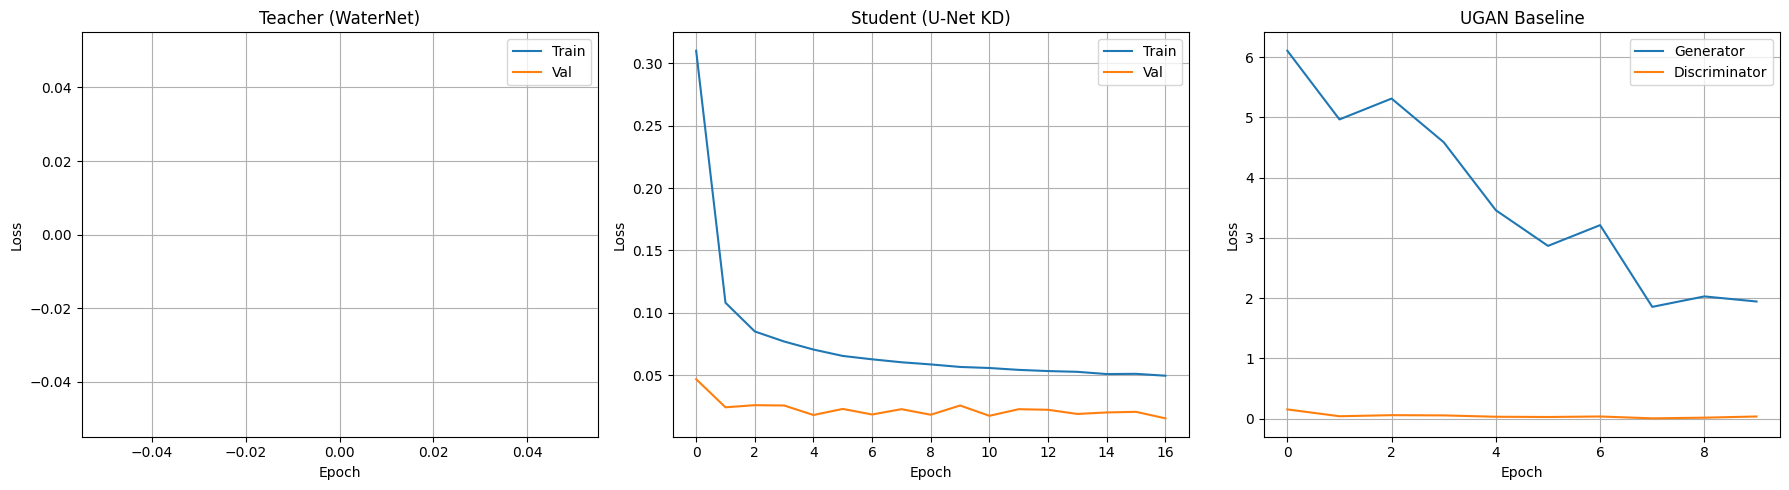

Training curves saved.


In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Teacher
axes[0].plot(history["teacher_train"], label="Train")
axes[0].plot(history["teacher_val"],   label="Val")
axes[0].set_title("Teacher (WaterNet)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

# Student
axes[1].plot(history["student_train"], label="Train")
axes[1].plot(history["student_val"],   label="Val")
axes[1].set_title("Student (U-Net KD)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

# UGAN
axes[2].plot(history["ugan_gen"],  label="Generator")
axes[2].plot(history["ugan_disc"], label="Discriminator")
axes[2].set_title("UGAN Baseline")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig(DRIVE_PATH + "training_curves_fixed.png", dpi=150)
plt.show()
print("Training curves saved.")

## Visual Comparasion  (5 test samples)

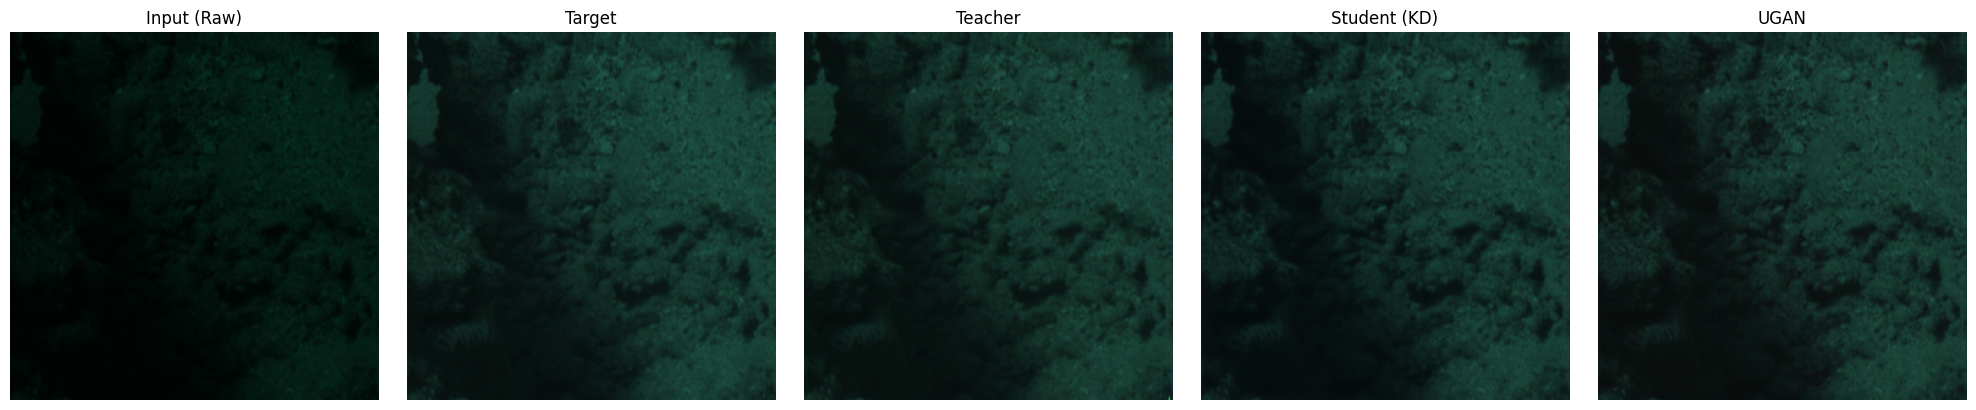

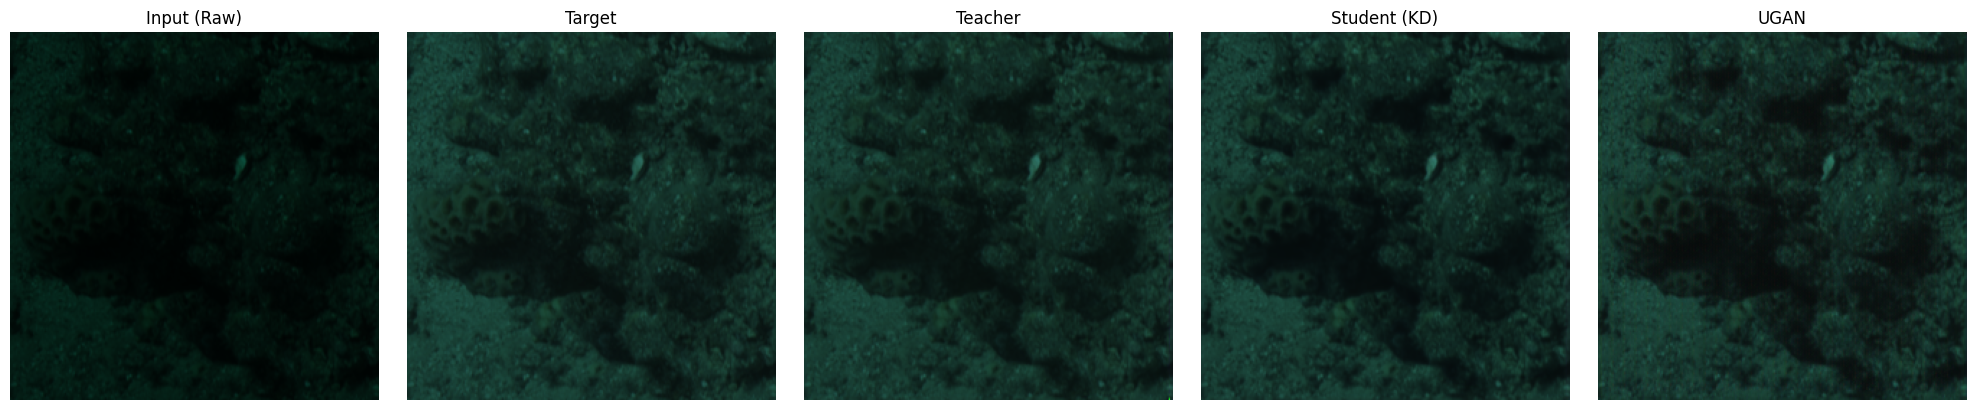

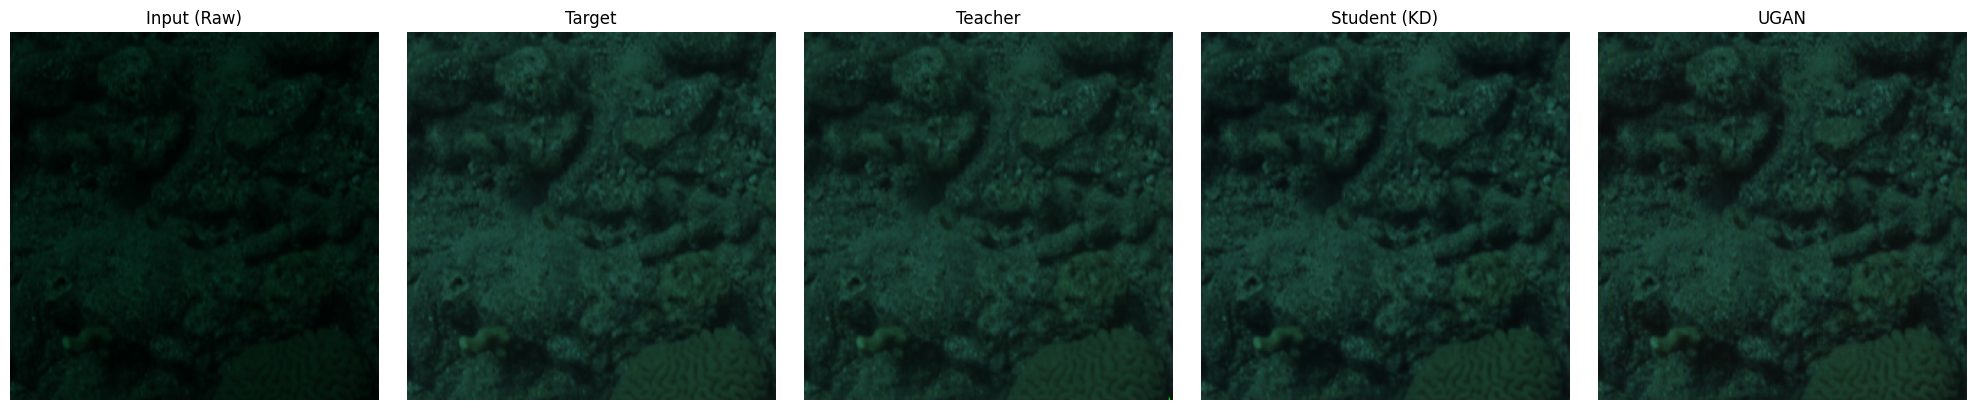

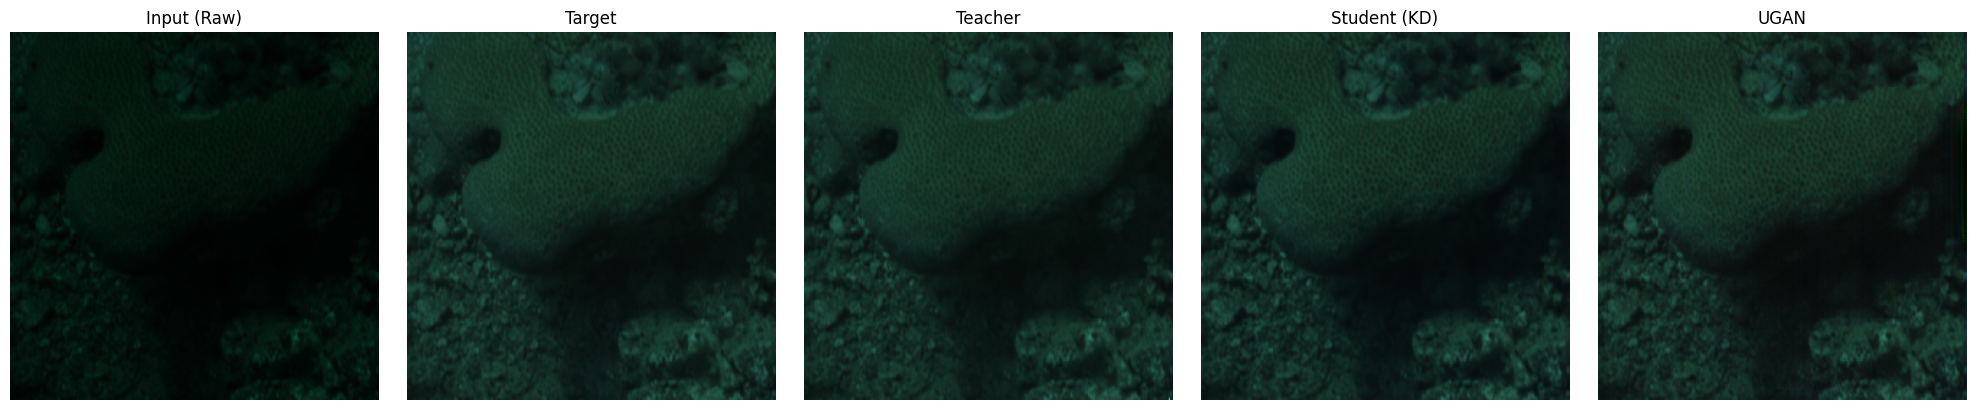

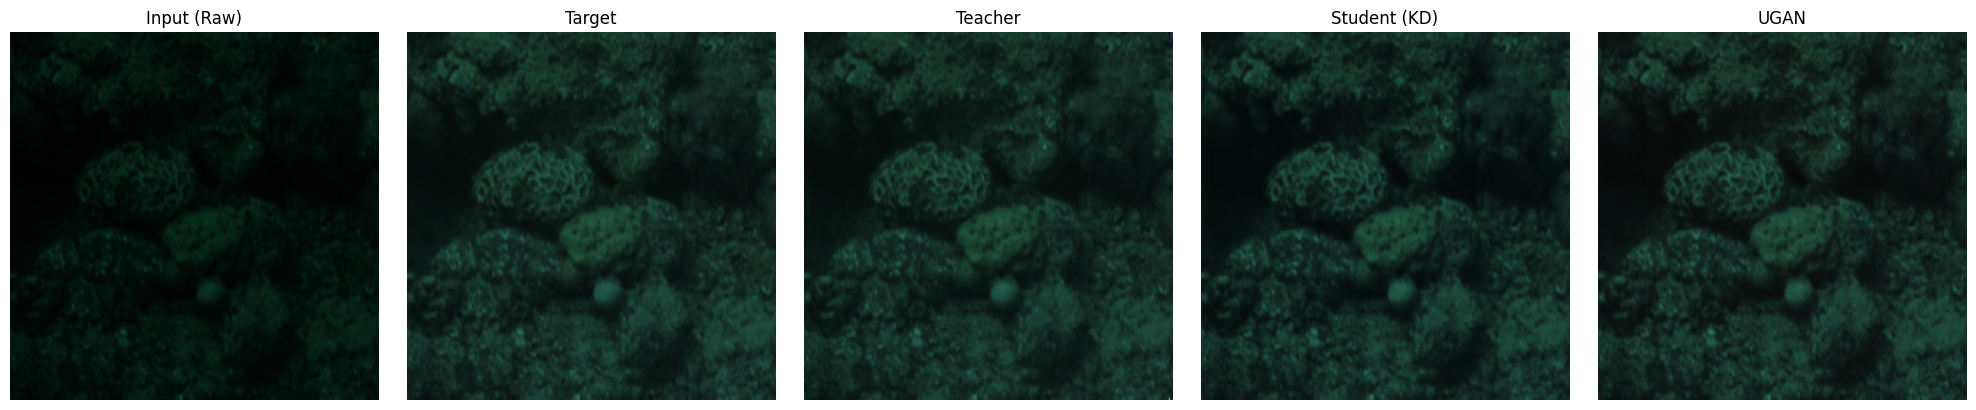

In [79]:
for raw_b, tgt_b in test_ds.take(1):
    for i in range(5):
        inp = raw_b[i:i+1]
        t_out = ((teacher (inp, training=False)[0].numpy() + 1) / 2).clip(0, 1)
        s_out = ((student (inp, training=False)[0].numpy() + 1) / 2).clip(0, 1)
        u_out = ((ugan_gen(inp, training=False)[0].numpy() + 1) / 2).clip(0, 1)
        raw   = ((inp[0].numpy() + 1) / 2).clip(0, 1)
        tgt   = ((tgt_b[i].numpy() + 1) / 2).clip(0, 1)

        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        for ax, img, title in zip(axes,
                                  [raw, tgt, t_out, s_out, u_out],
                                  ["Input (Raw)", "Target", "Teacher", "Student (KD)", "UGAN"]):
            ax.imshow(img); ax.set_title(title); ax.axis("off")
        plt.tight_layout()
        plt.show()

## UCIQE  (Underwater Color Image Quality Evaluation

In [92]:
def compute_uciqe(img_01):
    """img_01: H x W x 3 float32 in [0,1]. Returns scalar."""
    img_u8  = (img_01 * 255).astype(np.uint8)
    lab     = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
    chroma  = np.sqrt(a**2 + b**2)
    sigma_c = chroma.std()
    mu_l    = L.mean()
    # contrast: std of L
    sigma_l = L.std()
    # saturation
    hsv     = cv2.cvtColor(img_u8, cv2.COLOR_RGB2HSV).astype(np.float32)
    sat     = hsv[..., 1] / 255.0
    mu_s    = sat.mean()
    # UCIQE weights (standard)
    return 0.4680 * sigma_c + 0.2745 * sigma_l + 0.2576 * mu_s

## Full Evaluation

In [93]:
def evaluate_full(model, dataset, steps, name):
    psnr_vals, ssim_vals, uciqe_vals = [], [], []
    for step, (raw, target) in enumerate(dataset):
        if step >= steps:
            break
        pred = model(raw, training=False)
        p01  = tf.clip_by_value((pred   + 1) / 2, 0, 1)
        t01  = tf.clip_by_value((target + 1) / 2, 0, 1)
        psnr_vals.append(tf.reduce_mean(tf.image.psnr(t01, p01, 1.0)).numpy())
        ssim_vals.append(tf.reduce_mean(tf.image.ssim(t01, p01, 1.0)).numpy())
        # UCIQE on first image of batch
        uciqe_vals.append(compute_uciqe(p01[0].numpy()))

    psnr = np.mean(psnr_vals)
    ssim = np.mean(ssim_vals)
    uciqe = np.mean(uciqe_vals)
    print(f"{name:<25} {psnr:>10.2f} {ssim:>10.4f} {uciqe:>10.4f}")
    return psnr, ssim, uciqe

print("\n" + "="*60)
print(f"{'Model':<25} {'PSNR (dB)':>10} {'SSIM':>10} {'UCIQE':>10}")
print("="*60)
t_psnr, t_ssim, t_uciqe = evaluate_full(teacher,  test_ds, test_steps, "Teacher (WaterNet)")
s_psnr, s_ssim, s_uciqe = evaluate_full(student,  test_ds, test_steps, "Student (U-Net KD)")
u_psnr, u_ssim, u_uciqe = evaluate_full(ugan_gen, test_ds, test_steps, "Baseline (UGAN)")
print("="*60)

np.save(DRIVE_PATH + "eval_results_full.npy", {
    "teacher": (t_psnr, t_ssim, t_uciqe),
    "student":  (s_psnr, s_ssim, s_uciqe),
    "ugan":     (u_psnr, u_ssim, u_uciqe),
})


Model                      PSNR (dB)       SSIM      UCIQE
Teacher (WaterNet)             44.61     0.9963     4.5041
Student (U-Net KD)             44.87     0.9952     4.4627
Baseline (UGAN)                40.14     0.9598     4.8700
